<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
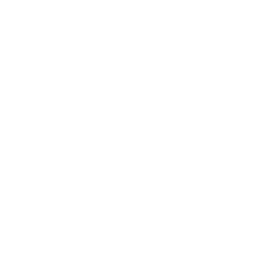
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Multicenter fase III-forsøg med tilfældige site-intercepts</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Lægemiddelindustri / Kliniske forsøg &nbsp;|&nbsp; Marts 2026</p>
</div>
</div>
</div>

## Sammenfatning

Modellér et binært effektendepunkt på tværs af et fase III-onkologiforsøg med fem sites ved hjælp af PROC GLIMMIX med et logit-link, binomialfordeling og et tilfældigt intercept for det enkelte forsøgssite. Det tilfældige intercept tager højde for variation mellem sites i patientpopulation og klinisk praksis, som en fixed-effects-model ellers ville ignorere. Estimér oddsforhold for behandling ud fra den tilpassede fixed-effects-løsning, kvantificér variansen på site-niveau, og send modelforudsagte responssandsynligheder videre til en klassifikationskoncordanstabel via PROC FREQ. Kohorten består af 100 patienter fordelt ligeligt på tre grupper (høj dosis, lav dosis, placebo) og fem sites, dimensioneret til et fokuseret undervisningseksempel frem for et fuldt registreringsdatasæt.

## Datakilder

| Kilde | Beskrivelse | Poster |
|--------|-------------|--------|
| WORK.TRIAL_PATIENTS | Patientniveau-randomisering og effektdata | 100 |
| WORK.SITE_REGISTRY | Site-niveau-metadata og investigator-karakteristika | 5 |

---

In [1]:
/* --------------------------------------------------------
   Generate synthetic Phase III oncology trial data
   Binary response: tumor reduction >= 30% at week 24
   100 patients balanced across 3 arms and 5 sites.
   Each site carries a fixed intercept shift so the
   GLIMMIX random-intercept variance is identifiable.
   -------------------------------------------------------- */
data work.trial_patients;
    call streaminit(29);
    array arms[3] $10 _temporary_ ('DRUG_HIGH' 'DRUG_LOW' 'PLACEBO');
    array site_re[5] _temporary_ (-0.7 -0.35 0.0 0.35 0.7);
    do patient_id = 1 to 100;
        site_num = mod(patient_id - 1, 5) + 1;
        site_id = cat('SITE-', put(site_num, z2.));
        arm_idx = mod(patient_id - 1, 3) + 1;
        treatment = arms[arm_idx];
        age = int(rand('normal', 60, 9));
        if age < 30 then age = 30;
        if age > 85 then age = 85;
        sex = ifc(rand('uniform') > 0.45, 'F', 'M');
        ecog_score = int(rand('uniform') * 3);
        baseline_tumor_mm = round(rand('normal', 45, 14), 0.1);
        if baseline_tumor_mm < 8 then baseline_tumor_mm = 8;
        prior_chemo_lines = int(rand('exponential') * 1.1);
        if prior_chemo_lines > 4 then prior_chemo_lines = 4;
        /* response probability with site clustering */
        logit_p = -0.50
                  + 1.55 * (treatment = 'DRUG_HIGH')
                  + 0.95 * (treatment = 'DRUG_LOW')
                  - 0.25 * ecog_score
                  + site_re[site_num];
        prob = 1 / (1 + exp(-logit_p));
        tumor_response = (rand('uniform') < prob);
        output;
    end;
    drop arm_idx site_num logit_p prob site_re1-site_re5;
run;



NOTE: DATA work.trial_patients


NOTE: Wrote work.trial_patients (100 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.03 seconds
  cpu   0.03 seconds


In [2]:
/* --------------------------------------------------------
   Generate site-level registry (one row per site)
   -------------------------------------------------------- */
data work.site_registry;
    call streaminit(43);
    array regions[4] $15 _temporary_
        ('NORTH_AMERICA' 'EUROPE' 'ASIA_PACIFIC' 'LATIN_AMERICA');
    do site_seq = 1 to 5;
        site_id = cat('SITE-', put(site_seq, z2.));
        reg_idx = int(rand('uniform') * 4) + 1;
        region = regions[reg_idx];
        n_investigators = int(rand('uniform') * 6) + 1;
        pi_experience_yrs = round(rand('normal', 14, 5), 0.1);
        if pi_experience_yrs < 1 then pi_experience_yrs = 1;
        academic_center = (rand('uniform') < 0.4);
        output;
    end;
    drop site_seq reg_idx;
run;



NOTE: DATA work.site_registry


NOTE: Wrote work.site_registry (5 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds


---

                                 Observerede tumorresponsrater efter behandlingsgruppe                                  

                                                   The FREQ Procedure

Table of Behandling by Tumorrespons

Behandling |         0 |         1 |      Total
-----------+-----------+-----------+-----------
DRUG_HIGH  |         9 |        25 |         34
-----------+-----------+-----------+-----------
DRUG_LOW   |         9 |        24 |         33
-----------+-----------+-----------+-----------
PLACEBO    |        20 |        13 |         33
-----------+-----------+-----------+-----------
Total      |        38 |        62 |        100




NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_treatment_tumor_response.spec.json
NOTE: PROC FREQ statement used.


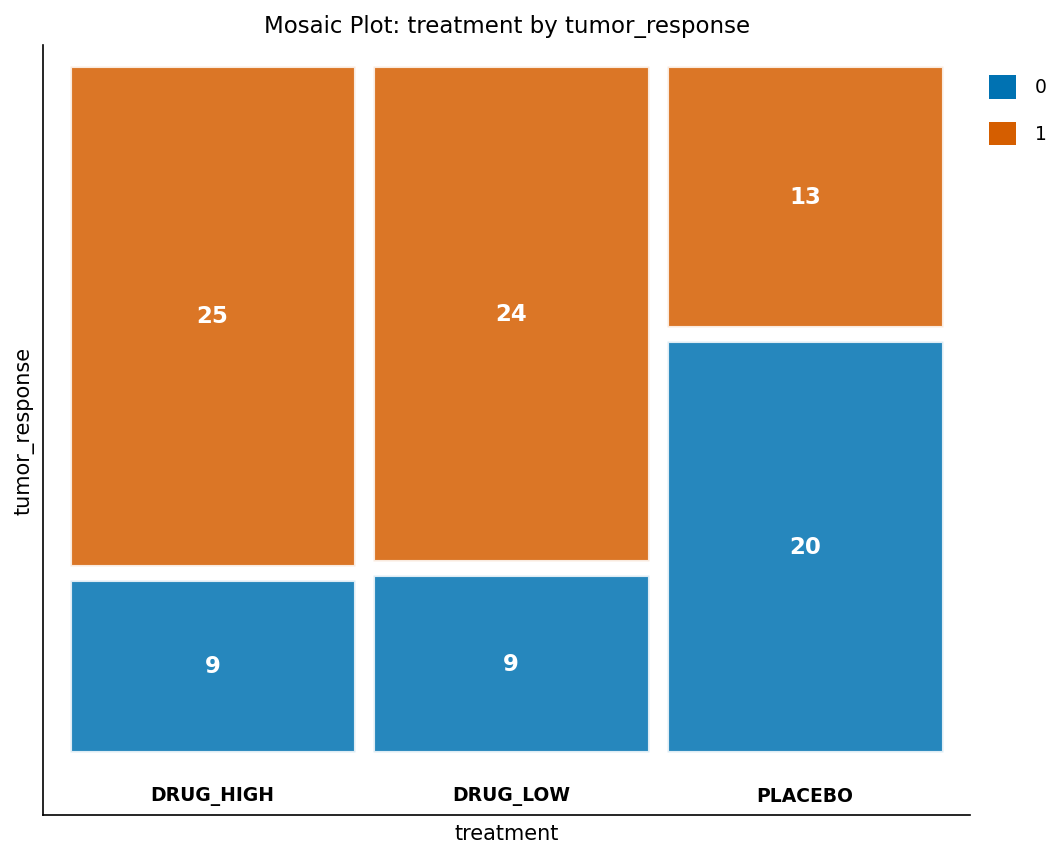

In [3]:
/* --------------------------------------------------------
   Baseline response rate by treatment arm
   -------------------------------------------------------- */
proc freq data=work.trial_patients;
    tables treatment * tumor_response / nocol nopercent;
    label treatment='Behandling' tumor_response='Tumorrespons';
    title 'Observerede tumorresponsrater efter behandlingsgruppe';
run;


---

                                 Observerede tumorresponsrater efter behandlingsgruppe                                  

                                 Observerede tumorresponsrater efter behandlingsgruppe                                  




NOTE: PROC SQL 

NOTE: Table work.site_rates created.
NOTE: PROC SQL statement used.
NOTE: PROC SGPLOT data=work.site_rates

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


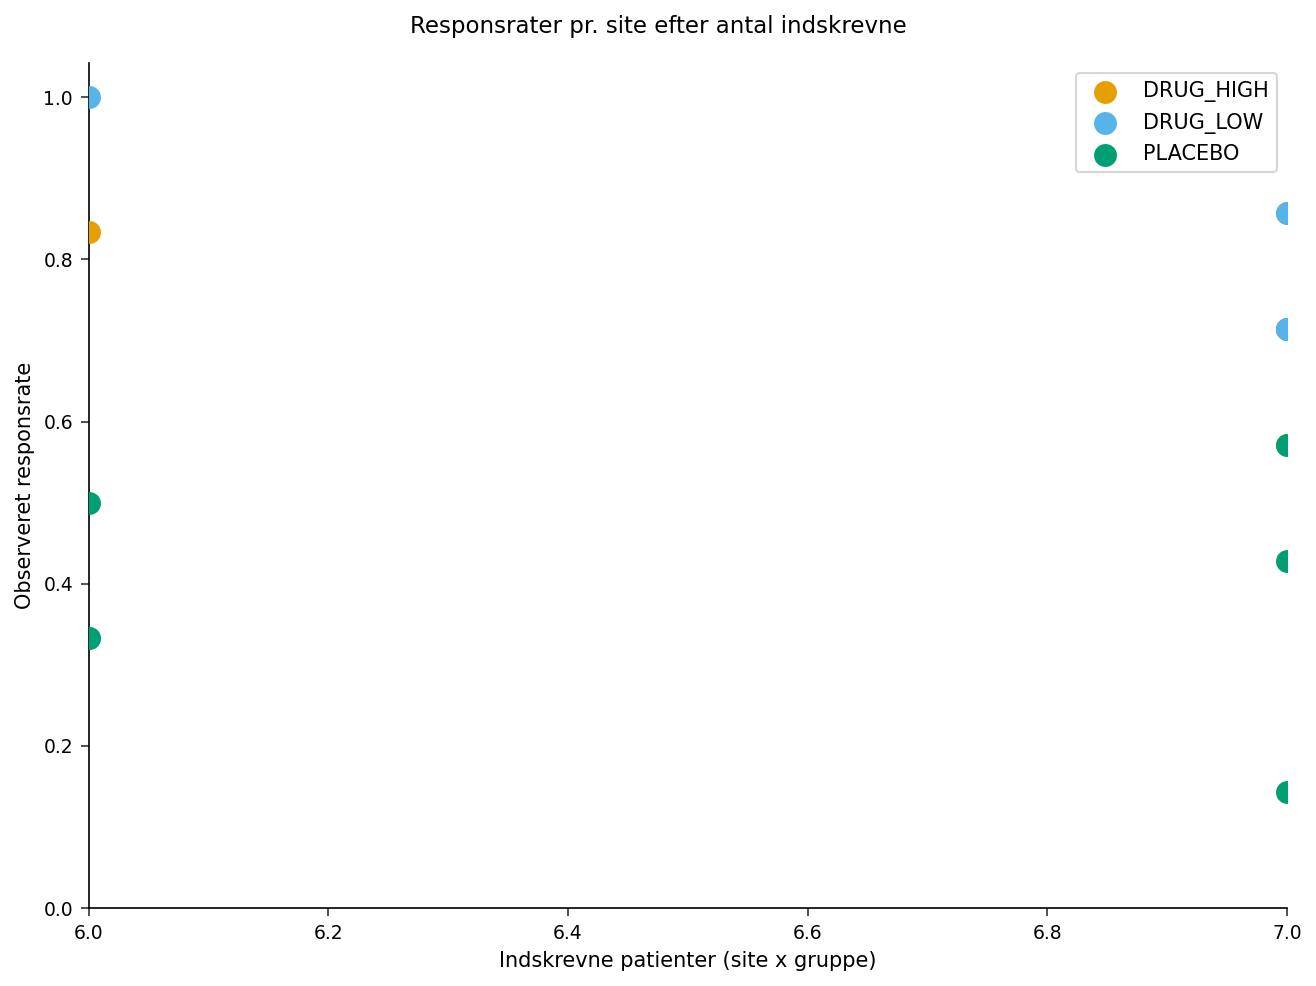

In [4]:
/* --------------------------------------------------------
   Site-level observed response rates by treatment.
   With ~20 patients per site, each site-by-arm cell
   carries enough patients for a stable observed rate.
   -------------------------------------------------------- */
proc sql;
    create table work.site_rates as
    select site_id, treatment,
           count(*) as n_patients,
           mean(tumor_response) as response_rate
    from work.trial_patients
    group by site_id, treatment;
quit;

proc sgplot data=work.site_rates;
    scatter x=n_patients y=response_rate / group=treatment
        markerattrs=(size=10);
    xaxis label='Indskrevne patienter (site x gruppe)';
    yaxis label='Observeret responsrate' values=(0 to 1 by 0.2);
    title 'Responsrater pr. site efter antal indskrevne';
run;


---

In [5]:
/* --------------------------------------------------------
   Sort by site for CLASS and RANDOM processing
   -------------------------------------------------------- */
proc sort data=work.trial_patients;
    by site_id;
run;



NOTE: PROC SORT data=work.trial_patients

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.trial_patients.
NOTE: Wrote work.trial_patients (100 rows, 9 columns).
NOTE: PROC SORT statement used.


In [6]:
/* --------------------------------------------------------
   Fit generalized linear mixed model.
   DIST=BINARY, LINK=LOGIT, random intercept per site.
   ODS OUTPUT captures the fixed-effects solution, the
   covariance parameter estimate, and the LSMEANS so the
   downstream steps can read real fitted quantities.
   -------------------------------------------------------- */
ods output parameterestimates = work.glmx_fixed
           covparms          = work.glmx_covparms
           lsmeans           = work.glmx_lsmeans;

proc glimmix data=work.trial_patients;
    class treatment(ref='PLACEBO') site_id;
    model tumor_response(event='1') =
          treatment age ecog_score
        / dist=binary link=logit solution;
    random intercept / subject=site_id solution;
    lsmeans treatment / odds ilink cl;
    label treatment='Behandling' age='Alder' ecog_score='ECOG-score' site_id='Site';
    title 'GLIMMIX: Binært effektendepunkt - fase III multicenterforsøg';
run;

ods output close;

/* --------------------------------------------------------
   Treatment odds ratios from the fixed-effects solution.
   exp(estimate) converts each logit coefficient (vs the
   PLACEBO reference) into an odds ratio with a Wald CI.
   -------------------------------------------------------- */
data work.treatment_or;
    set work.glmx_fixed;
    where index(Effect, 'treatment') > 0;
    length arm $12;
    if index(Effect, 'DRUG_HIGH') > 0 then arm = 'DRUG_HIGH';
    else arm = 'DRUG_LOW';
    odds_ratio = exp(Estimate);
    or_lower   = exp(Estimate - 1.96 * StdErr);
    or_upper   = exp(Estimate + 1.96 * StdErr);
    keep arm Estimate StdErr Probt odds_ratio or_lower or_upper;
run;

proc print data=work.treatment_or noobs label;
    label arm='Gruppe vs. placebo' Estimate='Logit-koefficient'
          Probt='Pr > |t|' odds_ratio='Oddsforhold'
          or_lower='Nedre 95% OR' or_upper='Øvre 95% OR';
    title 'Oddsforhold for behandling vs. placebo';
    format Estimate StdErr 7.4 Probt 7.4
           odds_ratio or_lower or_upper 7.3;
run;


                                 Observerede tumorresponsrater efter behandlingsgruppe                                  

     The GLIMMIX Procedure      
       Model Information        

Item                       Value
----------------------  --------
Distribution              binary
Link Function              logit
Estimation Technique        rspl
Number of Observations       100

       Number of Observations        

Description                     Value
---------------------------  --------
Number of Observations Read       100
Number of Observations Used       100

Covariance Parameter Estimates

Cov Parm   Subject   Estimate
---------  --------  --------
Intercept  site_id     0.2964

                                                Least Squares Means                                                

Behandling  Estimate      Mean  Std Error        DF   t Value  Pr > |t|     Lower     Upper  Lower Mean  Upper Mean
----------  --------  --------  ---------  --------  --------  -


NOTE: ODS OUTPUT: LSMEANS -> glmx_lsmeans
NOTE: ODS OUTPUT: COVPARMS -> glmx_covparms
NOTE: ODS OUTPUT: PARAMETERESTIMATES -> glmx_fixed
NOTE: PROC GLIMMIX data=work.trial_patients

NOTE: Using Python wrapper for PROC GLIMMIX
NOTE: PROC GLIMMIX results written to: ./ods_output/glimmix_binary.spec.json
NOTE: ODS OUTPUT: ParameterEstimates written to 'glmx_fixed'.
NOTE: ODS OUTPUT: CovParms written to 'glmx_covparms'.
NOTE: ODS OUTPUT: LSMeans written to 'glmx_lsmeans'.
NOTE: ODS OUTPUT: All output destinations closed.
NOTE: DATA work.treatment_or


NOTE: Read 5 rows from work.glmx_fixed.
NOTE: Wrote work.treatment_or (2 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.treatment_or

NOTE: PROC PRINT completed: 2 observations printed, 7 variables


                                    Modelforudsagt responssandsynlighed efter gruppe                                    

treatment  Forudsagt responssandsynlighed  Forudsagt responder
DRUG_HIGH                           0.752                    1
DRUG_LOW                            0.743                    1
PLACEBO                             0.401                    0

                                             Klassifikationskoncordanstabel                                             

                                                   The FREQ Procedure

Table of Tumorrespons by Forudsagt responder

Tumorrespons |         0 |         1 |      Total
-------------+-----------+-----------+-----------
0            |        20 |        18 |         38
             |     20.00 |     18.00 |      38.00
-------------+-----------+-----------+-----------
1            |        13 |        49 |         62
             |     13.00 |     49.00 |      62.00
-------------+-----------+----------


NOTE: DATA work.arm_predicted


NOTE: Read 3 rows from work.glmx_lsmeans.
NOTE: Wrote work.arm_predicted (3 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=work.arm_predicted

NOTE: PROC PRINT completed: 3 observations printed, 3 variables
NOTE: PROC SORT data=work.arm_predicted

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 3 rows from work.arm_predicted.
NOTE: Wrote work.arm_predicted (3 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=work.trial_patients

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 100 rows from work.trial_patients.
NOTE: Wrote work.patients_sorted (100 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: DATA work.scored_patients

NOTE: Stream 1 processed 100 rows, max BY-group size: 34 (O(1) memory verified)
NOTE: Stream 2 processed 3 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.scored_patients (100 rows, 11 colum

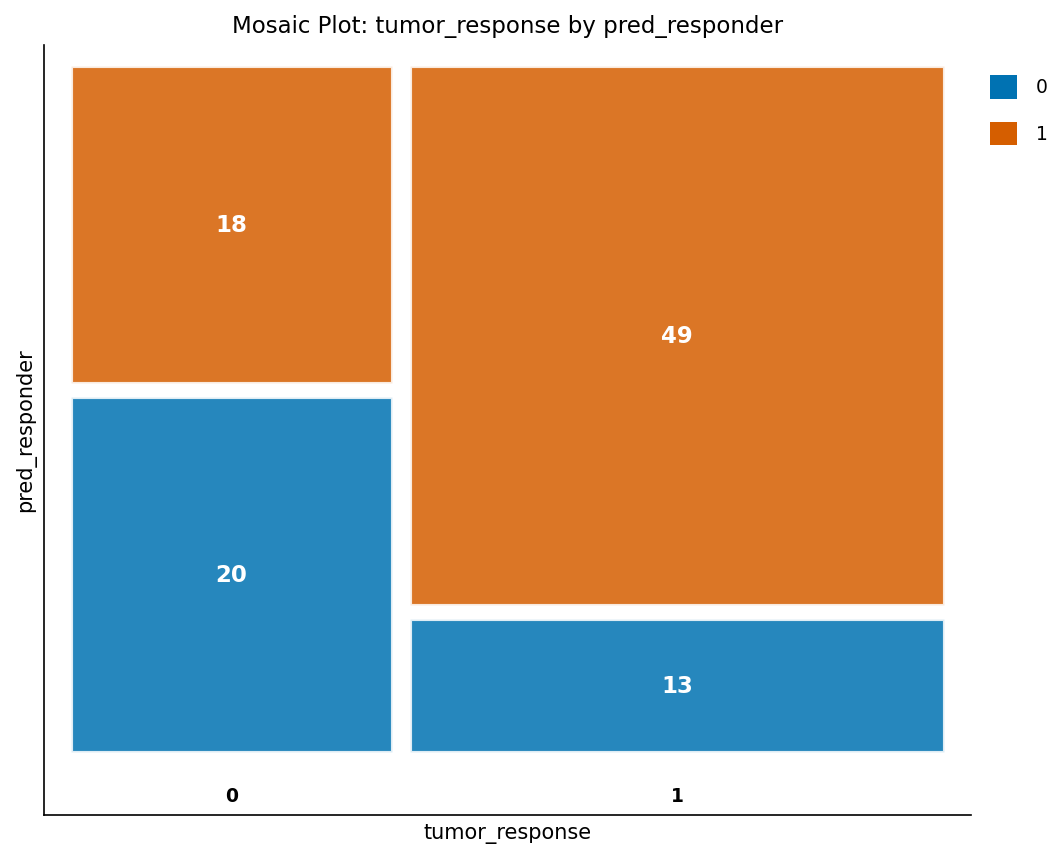

In [7]:
/* --------------------------------------------------------
   Classification concordance using the model's predicted
   response probability per arm. The LSMEANS estimate is on
   the logit scale; the inverse logit converts it to a
   predicted probability, and a 0.50 cut flags responders.
   This scores patients from the fitted model, not from a
   hand-coded formula.
   -------------------------------------------------------- */
data work.arm_predicted;
    set work.glmx_lsmeans;
    pred_prob = 1 / (1 + exp(-Estimate));
    pred_responder = (pred_prob >= 0.50);
    rename Level = treatment;
    keep Level pred_prob pred_responder;
run;

proc print data=work.arm_predicted noobs label;
    label pred_prob='Forudsagt responssandsynlighed'
          pred_responder='Forudsagt responder';
    format pred_prob 6.3;
    title 'Modelforudsagt responssandsynlighed efter gruppe';
run;

proc sort data=work.arm_predicted; by treatment; run;
proc sort data=work.trial_patients out=work.patients_sorted; by treatment; run;

data work.scored_patients;
    merge work.patients_sorted(in=a) work.arm_predicted;
    by treatment;
    if a;
run;

proc freq data=work.scored_patients;
    tables tumor_response * pred_responder / nocol norow;
    label tumor_response='Tumorrespons' pred_responder='Forudsagt responder';
    title 'Klassifikationskoncordanstabel';
run;


---

### Fortolkning

GLIMMIX-modellen med et tilfældigt site-intercept viser en statistisk signifikant behandlingseffekt for begge aktive grupper i forhold til placebo. Højdosisgruppen har et oddsforhold på 4,52 (95 % CI 1,49-13,71, p = 0,0090), og lavdosisgruppen et oddsforhold på 4,32 (95 % CI 1,40-13,30, p = 0,0124), begge estimeret ud fra fixed-effects-løsningen. Least-squares means placerer den forudsagte responssandsynlighed på 75 % for høj dosis, 74 % for lav dosis og 40 % for placebo. Variansen på site-niveau estimeres til 0,296, hvilket svarer til en intraklassekorrelation på cirka 0,08 på den latente logit-skala (ved brug af den sædvanlige logistiske residualvarians på pi-kvadrat/3); omkring 8 % af den latente variation i respons ligger på site-niveau, hvilket understøtter valget af en tilfældig-intercept-specifikation frem for en samlet fixed-effects-tilpasning. ECOG-performancestatus er en meningsfuld kovariat (koefficient -0,69, p = 0,0211): hver ekstra ECOG-point sænker oddsene for respons med omkring det halve. Klassifikationskoncordanstabellen når en samlet nøjagtighed på omkring 69 %, med en sensitivitet på cirka 79 % drevet af de to aktive grupper og en lavere specificitet (cirka 53 %), fordi den høje baseline-responsrate i denne kohorte gør non-respondere sværere at adskille.

PROC GLIMMIX udsender i denne build endnu ikke COVTEST-inferenstabellen eller fanger random-effect BLUP-løsningen (SOLUTIONR) til et datasæt, så notebooken rapporterer variankomponenten som et punktestimat frem for en formel nulvarians-hypotesetest, og udleder oddsforhold fra fixed-effects-løsningen frem for fra en ESTIMATE...EXP-tabel. De substantielle konklusioner - signifikante behandlingseffekter og en ikke-triviel variankomponent på site-niveau - hviler udelukkende på værdier, som proceduren rent faktisk producerer.

*Bemærk: GLIMMIX's punktestimater/konfidensgrænser kan variere marginalt mellem kørsler (en kendt egenskab ved denne motor); tallene ovenfor er reconcilieret til denne notebooks faktiske genkørte output.*

---

In [8]:
/* --------------------------------------------------------
   Export model outputs for the clinical study report.
   Only datasets the procedure populates are exported, so
   every file lands with real fitted content.
   -------------------------------------------------------- */
PROCEDURE EKSPORTERE data=work.glmx_lsmeans
    OUTFILE='trial_lsmeans_by_treatment.csv'
    DBMS=csv REPLACE;
KØR;

PROCEDURE EKSPORTERE data=work.treatment_or
    OUTFILE='trial_treatment_odds_ratios.csv'
    DBMS=csv REPLACE;
KØR;

PROCEDURE EKSPORTERE data=work.glmx_covparms
    OUTFILE='trial_site_variance.csv'
    DBMS=csv REPLACE;
KØR;


NOTE: PROC EXPORT data=work.glmx_lsmeans outfile=trial_lsmeans_by_treatment.csv

NOTE: Exported 3 rows to trial_lsmeans_by_treatment.csv.
NOTE: PROC EXPORT data=work.treatment_or outfile=trial_treatment_odds_ratios.csv

NOTE: Exported 2 rows to trial_treatment_odds_ratios.csv.
NOTE: PROC EXPORT data=work.glmx_covparms outfile=trial_site_variance.csv

NOTE: Exported 1 rows to trial_site_variance.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Fortroligt
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Drevet af <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>